# Facebook Engagement Analysis - EDA & Data Wrangling

Author: Nick Peril  
Project: TKH Phase I Portfolio Project   
Dataset: [Facebook Metrics (UCI Repository)](https://archive.ics.uci.edu/dataset/368/facebook+metrics)

## Objective
To explore the dataset and identify patterns that influence post engagement.  
To predict the total interactions of Facebook posts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading my dataset:

In [2]:
df = pd.read_csv('/Users/saadult/facebook-metrics/data/01_raw/dataset_Facebook.csv', sep=';')

Displaying the first 10 rows:

In [3]:
df. head(10)

,Page total likes,Type,Category,Post Month,Post Weekday,Post Hour,Paid,Lifetime Post Total Reach,Lifetime Post Total Impressions,Lifetime Engaged Users,Lifetime Post Consumers,Lifetime Post Consumptions,Lifetime Post Impressions by people who have liked your Page,Lifetime Post reach by people who like your Page,Lifetime People who have liked your Page and engaged with your post,comment,like,share,Total Interactions
0,139441,Photo,2,12,4,3,0.0,2752,5091,178,109,159,3078,1640,119,4,79.0,17.0,100
1,139441,Status,2,12,3,10,0.0,10460,19057,1457,1361,1674,11710,6112,1108,5,130.0,29.0,164
2,139441,Photo,3,12,3,3,0.0,2413,4373,177,113,154,2812,1503,132,0,66.0,14.0,80
3,139441,Photo,2,12,2,10,1.0,50128,87991,2211,790,1119,61027,32048,1386,58,1572.0,147.0,1777
4,139441,Photo,2,12,2,3,0.0,7244,13594,671,410,580,6228,3200,396,19,325.0,49.0,393
5,139441,Status,2,12,1,9,0.0,10472,20849,1191,1073,1389,16034,7852,1016,1,152.0,33.0,186
6,139441,Photo,3,12,1,3,1.0,11692,19479,481,265,364,15432,9328,379,3,249.0,27.0,279
7,139441,Photo,3,12,7,9,1.0,13720,24137,537,232,305,19728,11056,422,0,325.0,14.0,339
8,139441,Status,2,12,7,3,0.0,11844,22538,1530,1407,1692,15220,7912,1250,0,161.0,31.0,192
9,139441,Photo,3,12,6,10,0.0,4694,8668,280,183,250,4309,2324,199,3,113.0,26.0,142


#### Features and their descriptions:
Category - Manual content characterization: action (special offers and contests), product (direct advertisement, explicit brand content), and inspiration (non-explicit brand related content).  
Page total likes - Number of people who have liked the company's page.  
Type - Type of content (Link, Photo, Status, Video).  
Post month - Month the post was published (January, February, March, ...,December).  
Post hour - Hour the post was published (0, 1, 2, 3, 4, .... 23).  
Post weekday - Wleekday the post was published (Sunday, Monday,....Saturday).  
Paid - If the company paid to Facebook for advertising (yes, no).  
Lifetime post total reach - The number of people who saw a page post (unique users). ***-measures the quantity of unique fb user that saw the post***  
Lifetime post total impressions - Impressions are the number of times a post from a page is displayed, whether the post is clicked or not. People may see multiple impressions of the same post. For example, someone might see a Page update in News Feed once, and then a second time if a friend shares it. ***-measures the occurence/display of the post, doesn't matter the count of people who saw it***.  
Lifetime engaged users - The number of people who clicked anywhere in a post (unique users).  ***-count of unique person who clicked the post***.  
Lifetime post consumers - The number of people who clicked anywhere in a post. ***-count of unique person who clicked the post and consume ie. view photo, clicked the link, etc***.  
Lifetime post consumptions - The number of clicks anywhere in a post.  ***-total number of click, maybe multiple clicks from a single person***.  
Lifetime post impressions by people who have liked a page - Total number of impressions just from people who have liked a page.  
Lifetime post reach by people who like a page - The number of people who saw a page post because they have liked that page (unique users).  
Lifetime people who have liked a page and engaged with a post - The number of people who have liked a Page and clicked anywhere in a post (Unique users).  
Comments - Number of comments on the publication.  
Likes - Number of "Likes" on the publication.  
Shares - Number of times the publication was shared.  
Total interactions - The sum of "likes," "comments," and "shares" of the post.  

#### How do we measure the success of a facebook post?
1. Is it the number of interactions? (Sum of likes, comments, and shares) - Total interactions
2. Is it in the number of reach? (Count of unique fb users that *saw (exposure)*, the post) - Lifetime post total reach
3. Is it in the number of click on the post? (Count of unique fb users who *click* the post) - Lifetime engaged users
4. Is it in engagement rate (feature engineering) = Total interactions / Lifetime post total reach.  

#### What are the factors that drive post enagagements?
1. If you paid FB to increase the post's reach or impressions?
2. Is it the timing of the post? Weekends? Late afternoons? Night?
3. Is it the type of content? Plain text? Photo? Video Content? Link?

In [4]:
df.shape

(500, 19)

The dataset contains 500 rows and 19 columns.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   Page total likes                                                     500 non-null    int64  
 1   Type                                                                 500 non-null    object 
 2   Category                                                             500 non-null    int64  
 3   Post Month                                                           500 non-null    int64  
 4   Post Weekday                                                         500 non-null    int64  
 5   Post Hour                                                            500 non-null    int64  
 6   Paid                                                                 499 non-null    float64
 7   Lifetime

The dataset have both numerical and categorical variables.

In [6]:
df.describe().round(2)

,Page total likes,Category,Post Month,Post Weekday,Post Hour,Paid,Lifetime Post Total Reach,Lifetime Post Total Impressions,Lifetime Engaged Users,Lifetime Post Consumers,Lifetime Post Consumptions,Lifetime Post Impressions by people who have liked your Page,Lifetime Post reach by people who like your Page,Lifetime People who have liked your Page and engaged with your post,comment,like,share,Total Interactions
count,500.00,500.00,500.00,500.00,500.00,499.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,499.00,496.00,500.00
mean,123194.18,1.88,7.04,4.15,7.84,0.28,13903.36,29585.95,920.34,798.77,1415.13,16766.38,6585.49,609.99,7.48,177.95,27.27,212.12
std,16272.81,0.85,3.31,2.03,4.37,0.45,22740.79,76803.25,985.02,882.51,2000.59,59791.02,7682.01,612.73,21.18,323.40,42.61,380.23
min,81370.00,1.00,1.00,1.00,1.00,0.00,238.00,570.00,9.00,9.00,9.00,567.00,236.00,9.00,0.00,0.00,0.00,0.00
25%,112676.00,1.00,4.00,2.00,3.00,0.00,3315.00,5694.75,393.75,332.50,509.25,3969.75,2181.50,291.00,1.00,56.50,10.00,71.00
50%,129600.00,2.00,7.00,4.00,9.00,0.00,5281.00,9051.00,625.50,551.50,851.00,6255.50,3417.00,412.00,3.00,101.00,19.00,123.50
75%,136393.00,3.00,10.00,6.00,11.00,1.00,13168.00,22085.50,1062.00,955.50,1463.00,14860.50,7989.00,656.25,7.00,187.50,32.25,228.50
max,139441.00,3.00,12.00,7.00,23.00,1.00,180480.00,1110282.00,11452.00,11328.00,19779.00,1107833.00,51456.00,4376.00,372.00,5172.00,790.00,6334.00


### Key Observations from Descriptive Statistics:
1. There are missing values in the following columns: 'Paid', 'like', and 'share'. This means we need to clean this dataset and decide how to treat the missing values.
2. Standard deviation is very high, this means data is very spread. Total interaction's min is 0.00 (there are posts that didn't have any interactions at all) while max is 6334 (this could be viral posts), that's how spread the data is.
3. Knowing the Total interactions mean at 212.12 and the its max at 6334.00, there really are outliers. This could be the posts that gone viral. We'll see in the skewness of the distibution below.

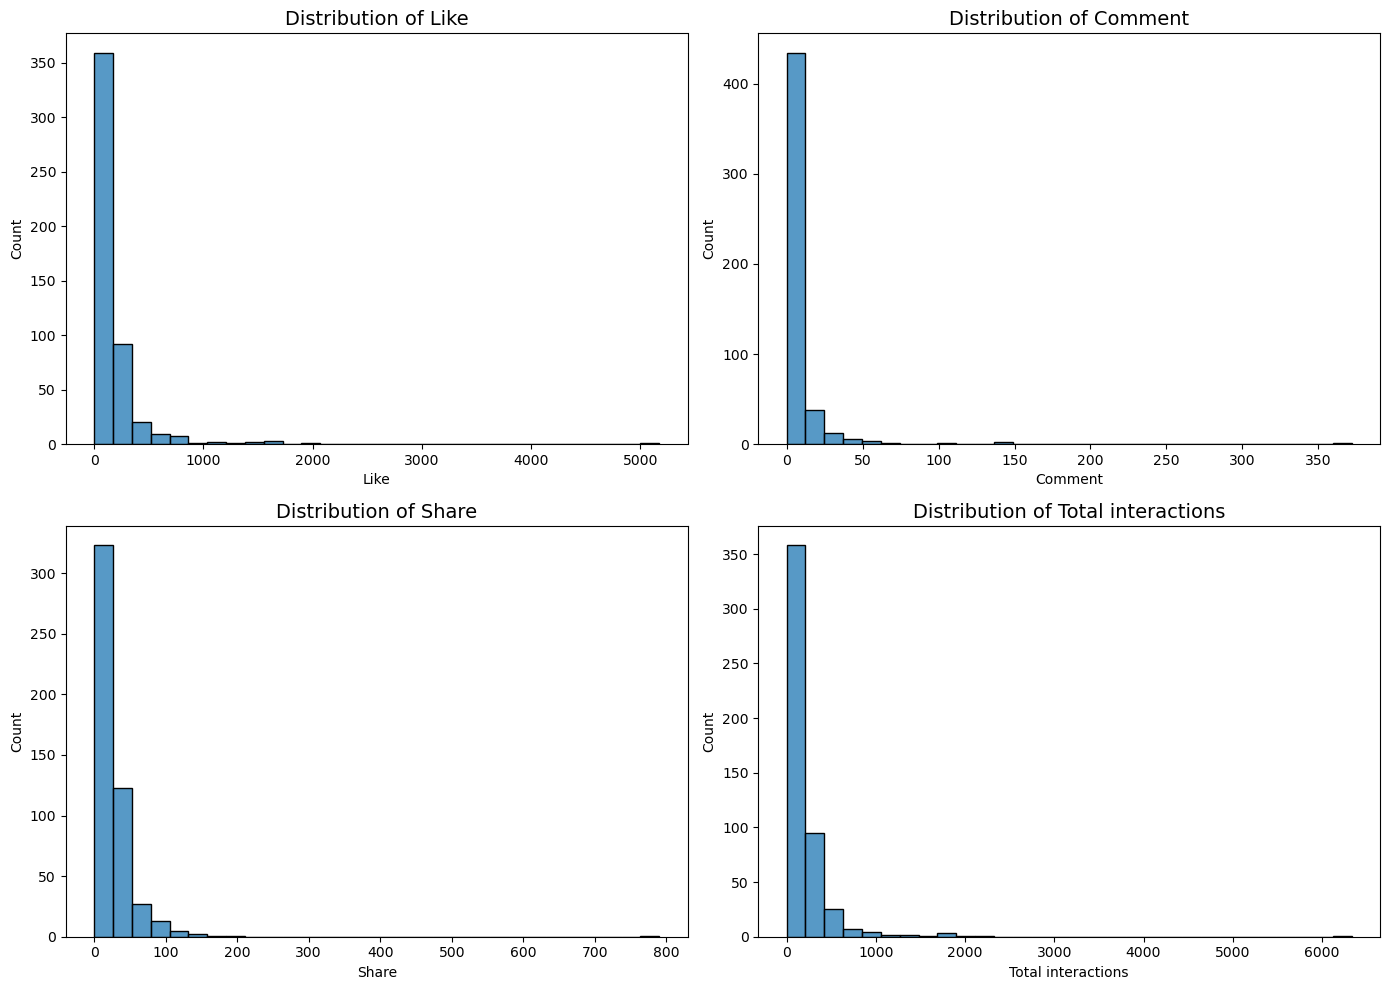

In [7]:
columns = ['like', 'comment', 'share', 'Total Interactions']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.histplot(df[col], bins=30, kde=False, ax=axes[i])
    axes[i].set_title(f'Distribution of {col.capitalize()}', fontsize=14)
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

The engagement-related variables (Like, Comment, Share, Total Interactions) exhibit strong right-skewness. Most posts receive relatively low engagement, while a small number of posts generate extremely high interaction counts (outliers).

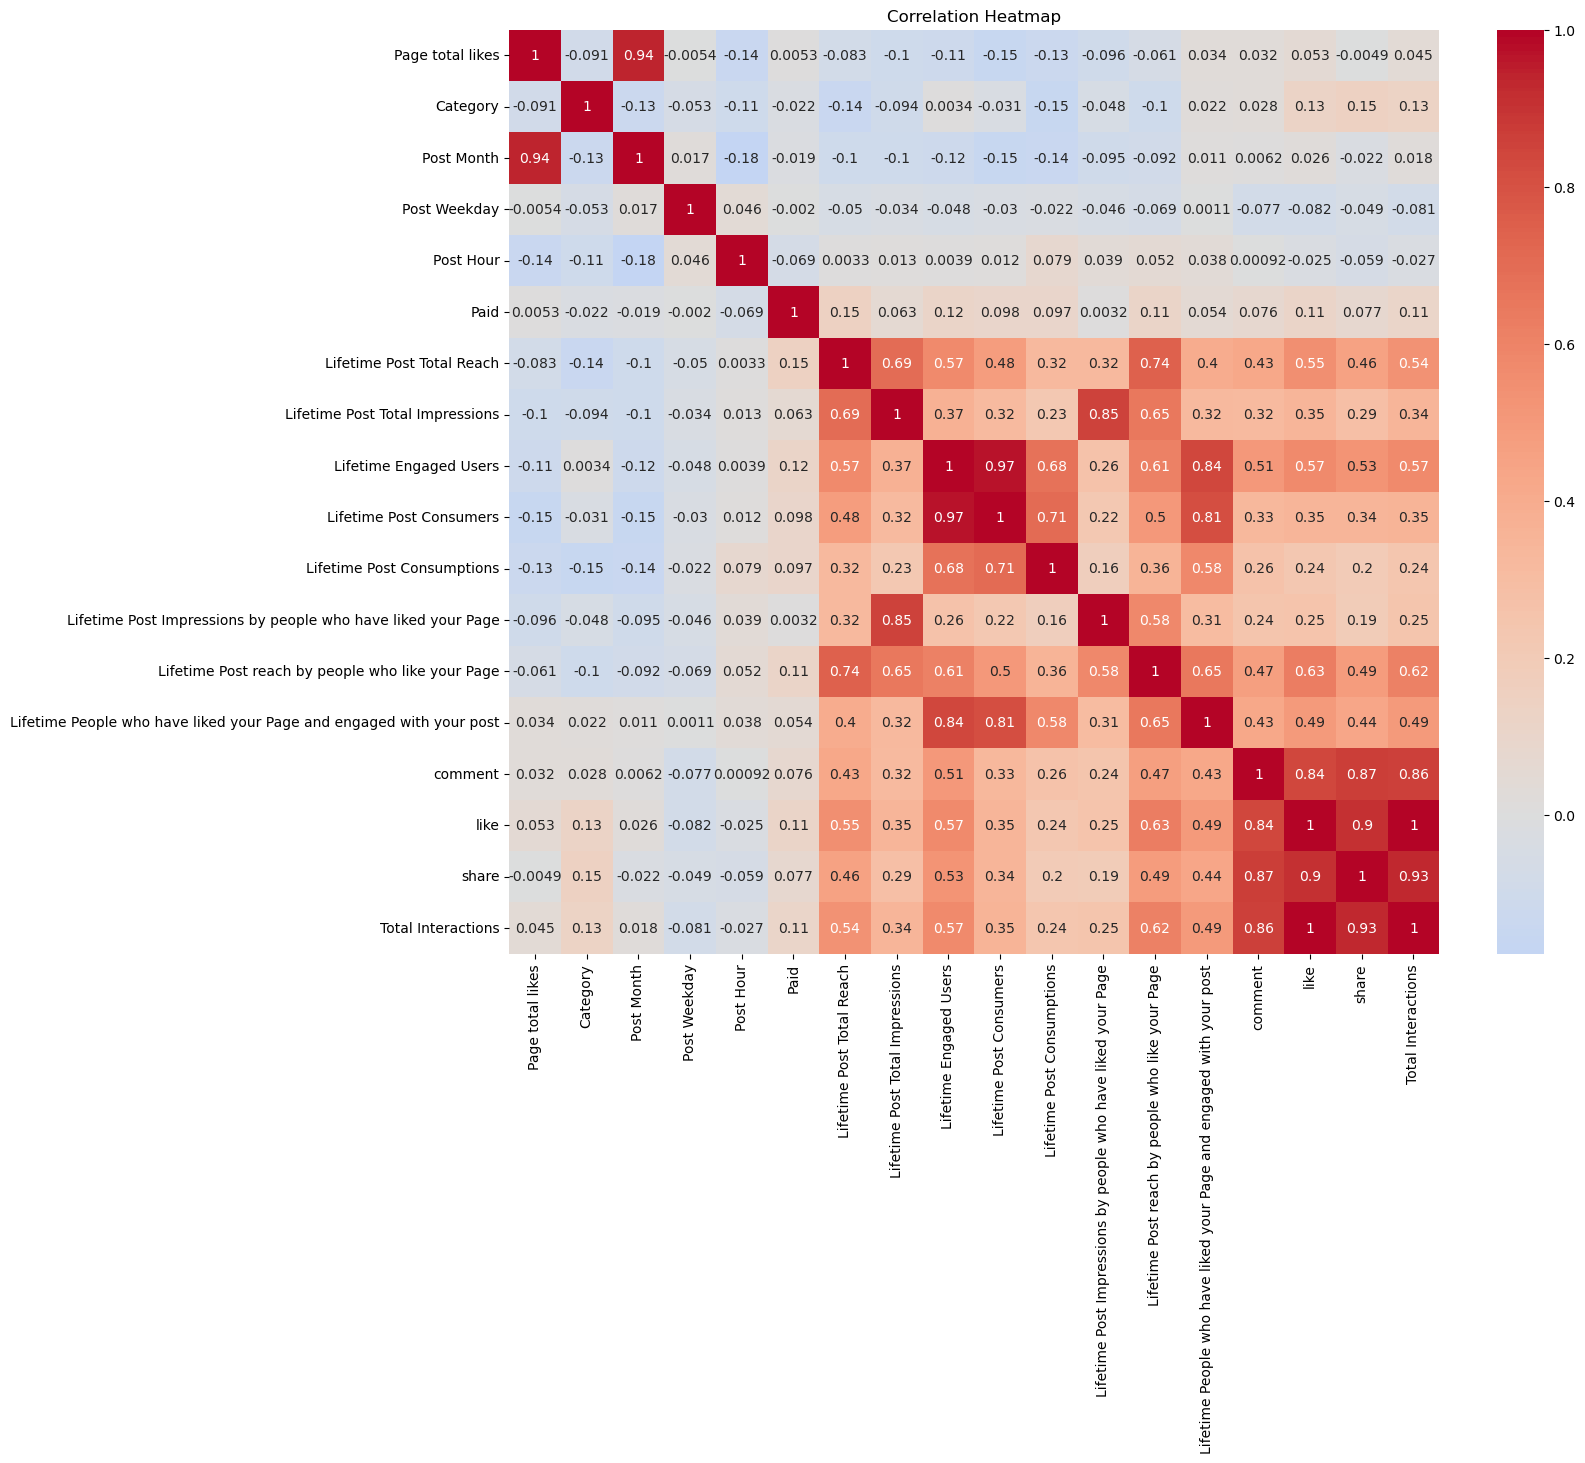

In [8]:
plt.figure(figsize=(15,12))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

Observations: 
1. The Heatmap shows the relation of 2 variables.
2. It's obvious that comment, like, and share are very bright because these variables makes up the total interactions, they are directly correlated.
3. Looking at the total reach, total impression and engage users, they are seem to be medium to bright colors. This means that posts that reach more people, tend to get more engagement.
4. Interestingly, paid post has a lighter color in interactions. This means that paid posts has only very minimal correlation or effect in total interactions.


## Defining success metric

For this analysis, I added a post success metric named ***Engagement Rate***. A post that reached 100,000 people and got 500 likes could be less efficient than a post that reached 2,000 people and got 300 likes. So I am going to make an engagement rate variable to measure engagement relative to exposure.

**Engagement Rate = Total Interactions / Lifetime Post Total Reach**

In [9]:
df['engagement_rate'] = df['Total Interactions'] / df['Lifetime Post Total Reach']

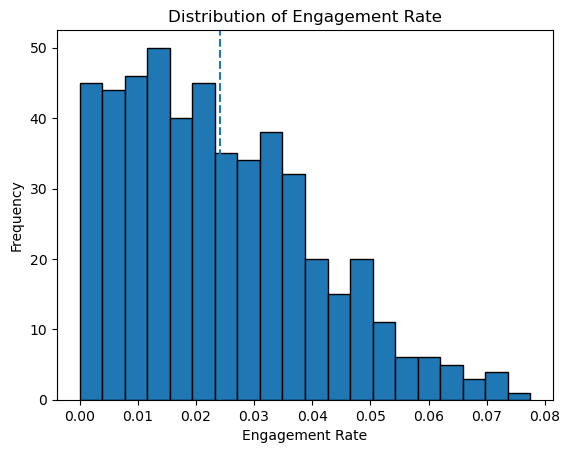

In [10]:
df['engagement_rate'].describe()
plt.hist(df['engagement_rate'], bins=20, edgecolor='black')
plt.axvline(df['engagement_rate'].mean(), linestyle='dashed')
plt.title('Distribution of Engagement Rate')
plt.xlabel('Engagement Rate')
plt.ylabel('Frequency')
plt.show()

The histogram shows a right-skewed distribution. While most post receive moderate active engagement relative to exposure, a small number of posts generate high enagagement rate, increasing overall variability.

### Is success based on number of interactions? reach? clicks? engagement rate?

In [11]:
df[['Total Interactions',
    'Lifetime Post Total Reach',
    'Lifetime Engaged Users',
    'engagement_rate']].corr()

,Total Interactions,Lifetime Post Total Reach,Lifetime Engaged Users,engagement_rate
Total Interactions,1.000000,0.538597,0.572159,0.158892
Lifetime Post Total Reach,0.538597,1.000000,0.570629,-0.327252
Lifetime Engaged Users,0.572159,0.570629,1.000000,-0.153463
engagement_rate,0.158892,-0.327252,-0.153463,1.000000


#### Correlation in Heat Map

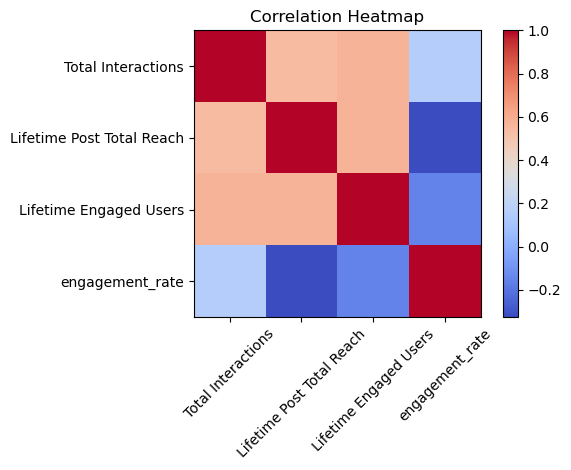

In [12]:
cols = [
    'Total Interactions',
    'Lifetime Post Total Reach',
    'Lifetime Engaged Users',
    'engagement_rate'
]

corr = df[cols].corr()

plt.figure()
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(cols)), cols)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Total interactions show a moderate positive relationship with reach and engaged users. Thjis means that when a post reaches more people, it usualy gets more likes, comments, and shares. So in general, the more people who see it, the more interactions it gets. However, engagement rate is weakly correlated with total interactions and negatively correlated with reach. When we look at engagement rate (how actively people interact compared to how many saw the post), the connection isn’t very strong. In fact, posts with a very large reach sometimes have a lower engagement rate. This suggests that while reaching more people can increase total interactions, it doesn’t always mean people are engaging more actively with the post.

##### Scale and efficiency are different things. Large reach does not equate high engagement rate. So what does success mean for this project? 
1. Total Interactions - if it is direct maesure of engagement volume (easy to interpret)
2. Reach - if it is a measure of visibility (but this could be better as a predictor)
3. Clicks/Engaged Users - similar to total interction but might create redundancy
4. Engagement Rate - if it is a measure of efficiency but this one is interesting because it negatively correlates with reach and may behave differently.

#### I decided to go with the one that is very solid to go with regression target - **Total Interactions**

## So what drives engagement?

### Paid Vs. Not Paid

In [13]:
df.groupby('Paid')['Total Interactions'].mean()

Paid
0.0    186.852778
1.0    278.230216
Name: Total Interactions, dtype: float64

<Axes: xlabel='Paid', ylabel='Total Interactions'>

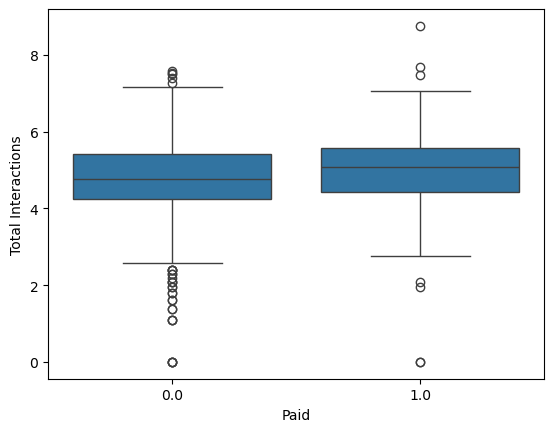

In [14]:
sns.boxplot(x='Paid', y=np.log1p(df['Total Interactions']), data=df)

The boxplot indicates that the median in Paid posts is slightly higher than the Not Paid, this suggests thaty paid post tend to generate higher total interactions on average. In terms of spread, they are similar but paid posts appear slightly shifted upward, this suggests paid posts consistently perform slightly better in volume. Outliers exist and higher in Paid posts, this means that paid posts may have higher upside potential.

### Timing (Post Month, Weekday, Hour)

In [15]:
weekday_map = {
    1: 'Sun',
    2: 'Mon',
    3: 'Tue',
    4: 'Wed',
    5: 'Thu',
    6: 'Fri',
    7: 'Sat'
}

In [16]:
weekday_engagement = df.groupby('Post Weekday')['Total Interactions'].mean().sort_index()

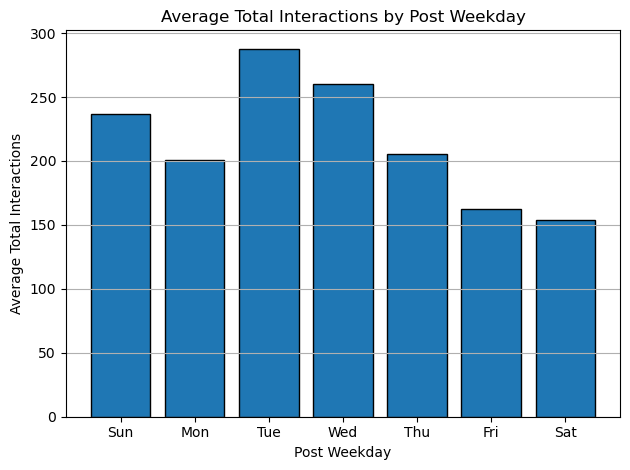

In [17]:
labels = [weekday_map[i] for i in weekday_engagement.index]

plt.figure()

plt.bar(labels,
        weekday_engagement.values,
        edgecolor='black')

plt.title("Average Total Interactions by Post Weekday")
plt.xlabel("Post Weekday")
plt.ylabel("Average Total Interactions")

plt.grid(axis='y')
plt.tight_layout()
plt.show()

The average total interactions has seen the highest during Tuesdays while lowest during Saturdays. It is interesting that Saturday got the lowest average total interactions when it is the weekend.

In [18]:
hour_engagement = df.groupby('Post Hour')['Total Interactions'].mean().sort_index()

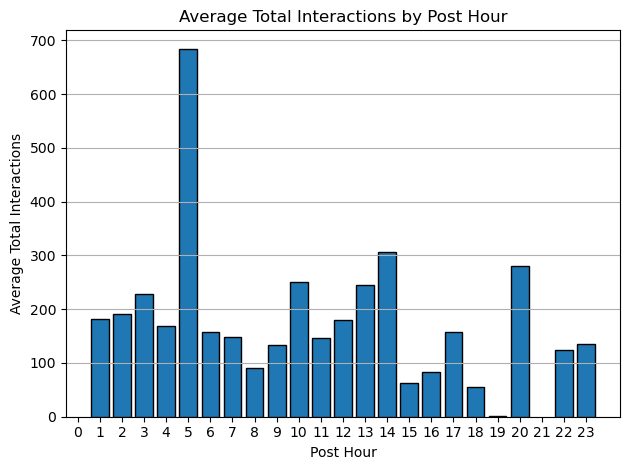

In [19]:
plt.bar(hour_engagement.index,
        hour_engagement.values,
        edgecolor='black')

plt.title("Average Total Interactions by Post Hour")
plt.xlabel("Post Hour")
plt.ylabel("Average Total Interactions")

plt.xticks(range(24))
plt.grid(axis='y')
plt.tight_layout()
plt.show()

The average total interactions has seen the highest during the post made on the 5th hour while there are some post hours that didn't record any interactions. Most of the post hours record average total interactions of below 200. It was not clearly described in the dataset about the timezone for the variable. It could be based on the original Facebook page's local time or the datset creator's export timezone.

### Content Type

In [20]:
type_engagement = df.groupby('Type')['Total Interactions'].mean()

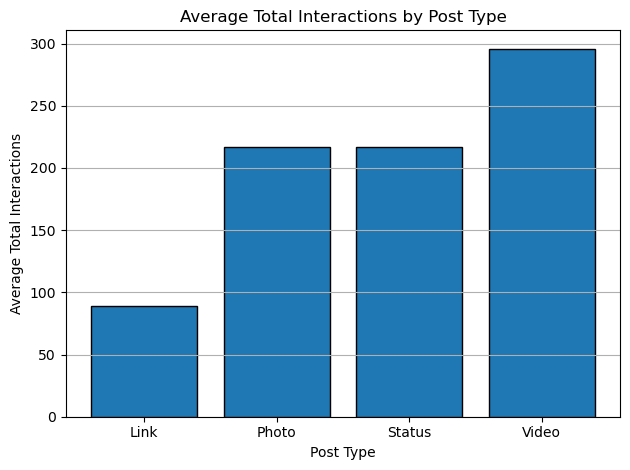

In [21]:
plt.bar(type_engagement.index,
        type_engagement.values,
        edgecolor='black')

plt.title("Average Total Interactions by Post Type")
plt.xlabel("Post Type")
plt.ylabel("Average Total Interactions")

plt.xticks(range(4))
plt.grid(axis='y')
plt.tight_layout()
plt.show()

Posts that contains video materials got the highest average total interactions. This means that video posts are more engaging compare to other types. The post type that ythat got the lowest average total interactions is the link.

### Checking for Outliers

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns

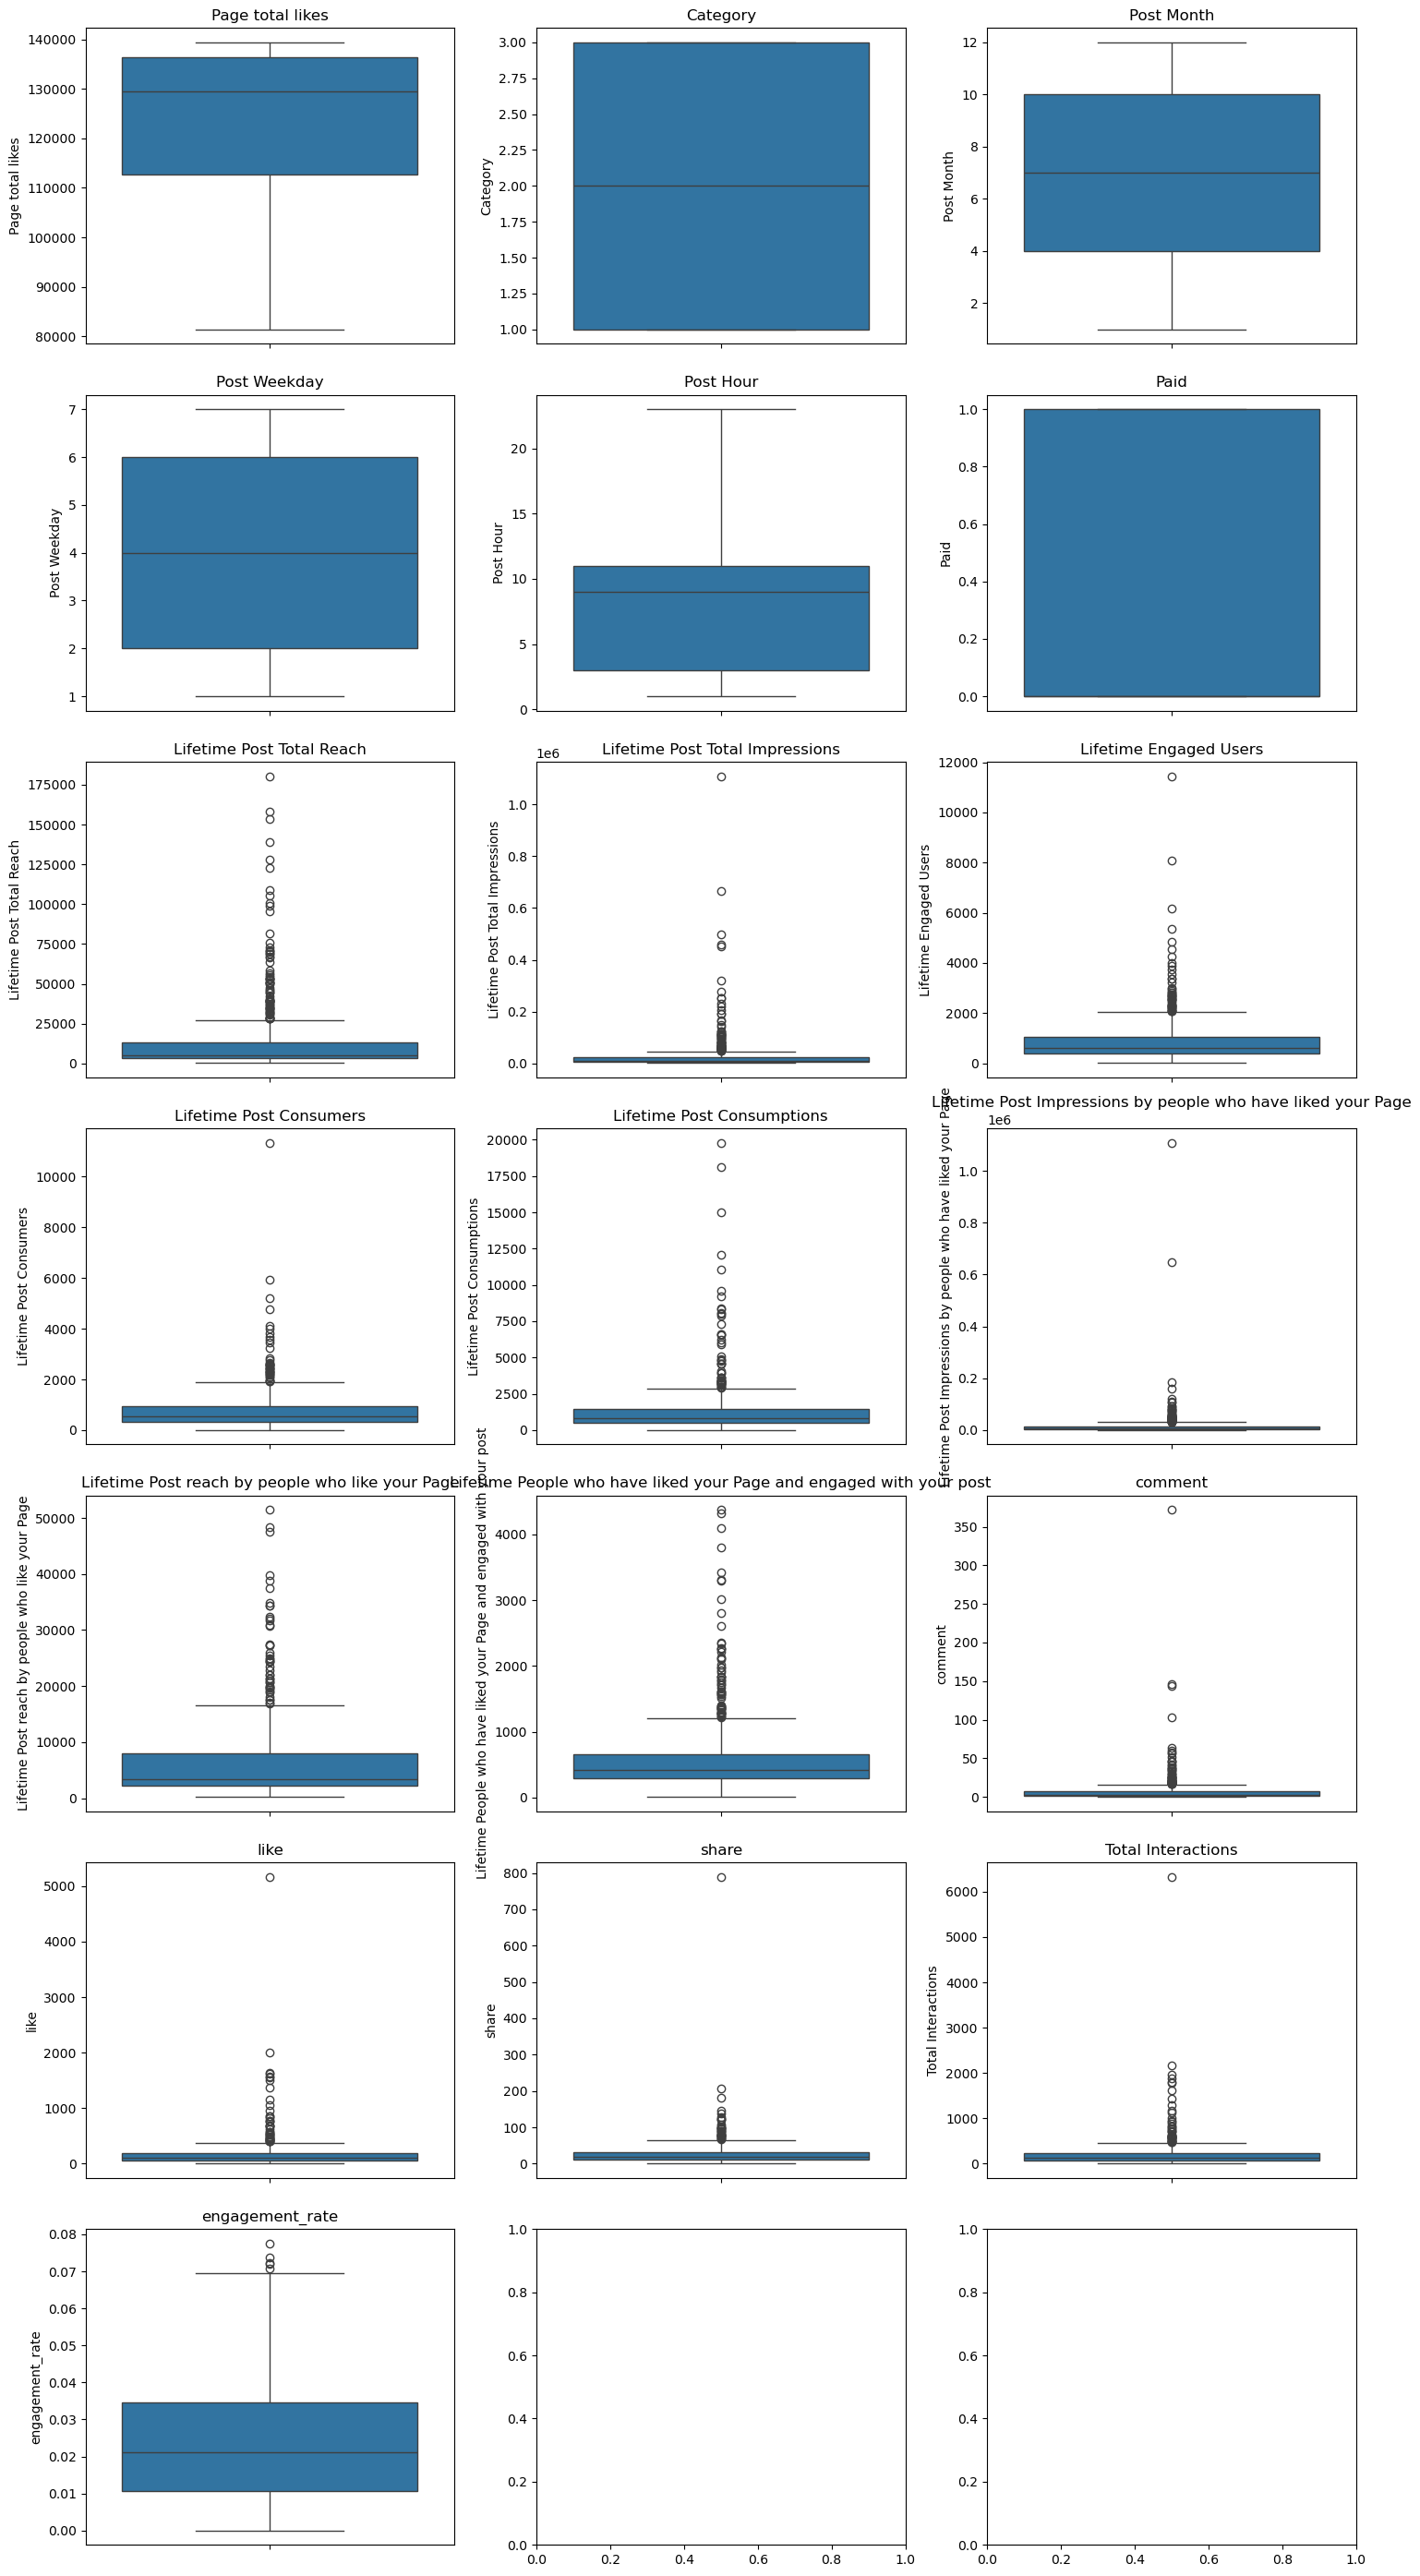

In [27]:
cols = 3
rows = (len(numeric_cols) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, rows*4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

The boxplots revealed potential outliers for several features. Many engagement-related metrics showed extreme values which likely represent hgihly viral posts rather than data errors. Because of this, I think I will retain these outliers in the dataset to preserve meaningful engagement behavior. However, I think features such as like, comment , and share will be removed because they directly contribute to the calculation of the Total Interactions, which is my target variable.